# 01.3 — Functions, classes and reliable image files

**CPU · Local temporary files · No downloads**

## Learning Objectives

Separate array transformations from file handling, explain a small class, use a dataclass configuration, save/reload a PNG and respond usefully to a missing file.

## Prerequisites

Functions, NumPy RGB arrays, indexing and clipping. This notebook creates all its own data. Temporary files are cleaned up automatically; the mini project later saves persistent reports in a folder you choose.

## 1. Introduction

An experiment becomes reusable when another person can call it with a different image and receive a predictable result. We need an input contract, named parameters and explicit file errors. A library function should not depend on a variable created in a previous notebook.

In [1]:
import json
from pathlib import Path
from tempfile import TemporaryDirectory

import cv2
import matplotlib.pyplot as plt
import numpy as np

from cvzero.images import adjust_brightness, adjust_channels, image_summary
from cvzero.io import load_rgb, save_json, save_rgb
from cvzero.lab import LabConfig, transform
from cvzero.synthetic import make_scene

original = make_scene(80, 120, seed=42)
print("Input contract:", original.shape, original.dtype, "RGB")

Input contract: (80, 120, 3) uint8 RGB


## 2. Intuition

Think of an image editor as a small workshop. A transformation function is a tool; a configuration is the written setting on that tool; the file loader brings material into the workshop. Keeping these responsibilities separate makes it easier to discover whether a failure came from the input file or from the transformation.

A class is useful when related state and behavior need to travel together. We will use one to preserve an original image and produce edited versions. It is a design choice, not a requirement that every function must become a class.

## 3. Mathematical Foundation

Our two-stage operation is $A=\operatorname{clip}(I+\Delta,0,255)$, then $J=\operatorname{clip}(A g,0,255)$. $I$ is the input array, $\Delta$ the brightness offset, $g$ the channel gains and $J$ the output. Each stage rounds before storing `uint8`.

For a channel value of 250, offset 20 and gain 0.5: first clip 270 to 255, then round 127.5 to 128. Multiplying first would instead produce 125+20=145. Writing the order explicitly prevents two implementations from silently doing different work.

In [2]:
single = np.array([[[250, 100, 20]]], dtype=np.uint8)
configuration = LabConfig(brightness=20, gains=(0.5, 1.0, 1.0))
computed = transform(single, configuration)
print("Brightness then gains:", computed.tolist())
assert computed.tolist() == [[[128, 120, 40]]]

Brightness then gains: [[[128, 120, 40]]]


## 4. Visual Explanation

Preserve the original so a side-by-side comparison uses the same source. The plot is a check on the data path: settings should explain the visible result.

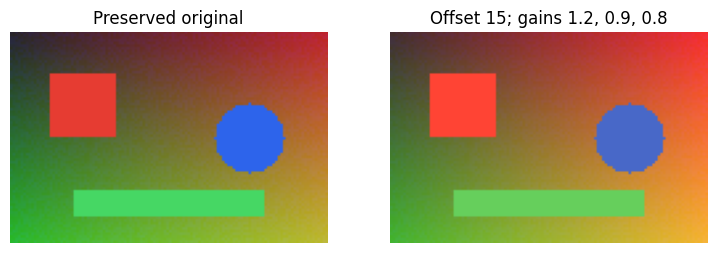

In [3]:
configuration = LabConfig(brightness=15, gains=(1.2, 0.9, 0.8))
edited = transform(original, configuration)
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].imshow(original)
axes[0].set_title("Preserved original")
axes[1].imshow(edited)
axes[1].set_title("Offset 15; gains 1.2, 0.9, 0.8")
for ax in axes:
    ax.set_axis_off()
plt.show()

## 5. Basic Implementation

The next function composes two reusable operations. Its annotation says an array comes in and an array comes out. The functions it calls validate the actual data. Its docstring declares the order; nothing is loaded or saved inside the arithmetic function.

In [4]:
def edit_rgb(rgb: np.ndarray, delta: float, gains: tuple[float, float, float]) -> np.ndarray:
    """Return a new RGB array: brightness first, then channel gains."""
    brighter = adjust_brightness(rgb, delta)
    return adjust_channels(brighter, gains)


np.testing.assert_array_equal(edit_rgb(original, 15, (1.2, 0.9, 0.8)), edited)


class ImageEditor:
    """Keep a private copy of the source and generate independent edits."""

    def __init__(self, rgb):
        self._original = rgb.copy()

    def apply(self, delta=0, gains=(1.0, 1.0, 1.0)):
        return edit_rgb(self._original, delta, gains)

    def describe(self):
        return image_summary(self._original)


editor = ImageEditor(original)
preview = editor.apply(delta=-15)
print("Editor size:", editor.describe()["width"], "x", editor.describe()["height"])
assert not np.shares_memory(preview, original)

Editor size: 120 x 80


`self` identifies the current object. `__init__` copies the initial data; `apply` is a method using that stored data. The underscore is a Python naming convention, not a security barrier. The dataclass `LabConfig` used earlier reduces routine parameter storage; you can inspect its small definition in `src/cvzero/lab.py`.

## 6. OpenCV Implementation

Write a known RGB array as PNG, read it with OpenCV and explicitly convert the returned BGR array. Check that decoding succeeded. A `TemporaryDirectory` context automatically removes the generated file when the block ends.

In [5]:
with TemporaryDirectory(prefix="cvzero-lesson-") as directory:
    path = Path(directory) / "known-image.png"
    save_rgb(path, original)
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError("OpenCV could not decode the generated PNG.")
    opencv_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    pillow_rgb = load_rgb(path)
    np.testing.assert_array_equal(opencv_rgb, original)
    np.testing.assert_array_equal(pillow_rgb, original)
    print("PNG round trip and RGB conversion: exact match")

PNG round trip and RGB conversion: exact match


## 7. From-Scratch Implementation

Here is the tiny scalar reference behind the editor's brightness step. It allocates new storage, visits each channel, computes using Python numbers and then clips. It deliberately favors visibility over speed. File decoding is handled by image libraries; writing a PNG decoder would distract from this chapter's objective.

In [6]:
def brightness_reference(rgb, delta):
    output = np.empty_like(rgb)
    for y in range(rgb.shape[0]):
        for x in range(rgb.shape[1]):
            for channel in range(3):
                value = float(rgb[y, x, channel]) + delta
                output[y, x, channel] = round(min(255.0, max(0.0, value)))
    return output


small = original[:8, :10].copy()
np.testing.assert_array_equal(brightness_reference(small, -20), adjust_brightness(small, -20))
print("Reference and reusable function agree on the small image.")

Reference and reusable function agree on the small image.


## 8. Experiment

Save both a PNG and JSON metadata with relative filenames. JSON needs ordinary Python values, so the image summary converts NumPy values to lists and integers. Use an explicit exception handler for the missing input; the failure is expected and explained, not silently ignored.

In [7]:
with TemporaryDirectory(prefix="cvzero-file-experiment-") as directory:
    run_dir = Path(directory)
    save_rgb(run_dir / "edited.png", edited)
    report = {
        "filename": "edited.png",
        "seed": 42,
        "brightness": 15,
        "gains": [1.2, 0.9, 0.8],
        "image": image_summary(edited),
    }
    save_json(run_dir / "summary.json", report)
    saved = json.loads((run_dir / "summary.json").read_text(encoding="utf-8"))
    print("Saved files:", sorted(path.name for path in run_dir.iterdir()))
    print("Recorded mean RGB:", saved["image"]["mean_rgb"])
    try:
        load_rgb(run_dir / "missing.png")
    except FileNotFoundError:
        print("Expected failure: missing.png does not exist. Check the input path.")
    else:
        raise AssertionError("The missing file should have failed.")

Saved files: ['edited.png', 'summary.json']
Recorded mean RGB: [154.038125, 114.36375, 62.726875]
Expected failure: missing.png does not exist. Check the input path.


## 9. Visualization

The same editor can produce independent versions with different settings. Compare each output with the source, and verify numerically that a zero-change configuration gives the original back.

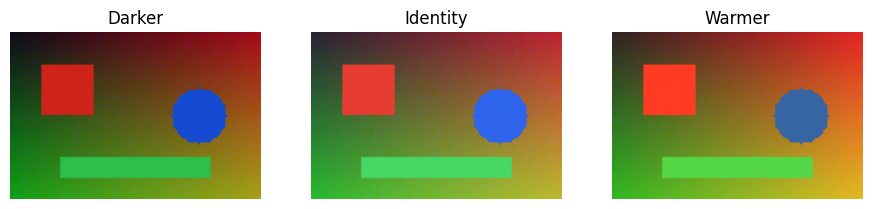

In [8]:
versions = [
    ("Darker", editor.apply(-25)),
    ("Identity", editor.apply(0)),
    ("Warmer", editor.apply(0, (1.2, 1.0, 0.7))),
]
np.testing.assert_array_equal(versions[1][1], original)
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, (name, version) in zip(axes, versions, strict=True):
    ax.imshow(version)
    ax.set_title(name)
    ax.set_axis_off()
plt.show()

## 10. Real-World Application

This separation of loading, configuration, pure transformations and reporting scales into batch preprocessing. Later training datasets also need these contracts. For now, PNG and JSON make a small experiment inspectable without a database or web server.

## 11. Common Mistakes

- Assuming paths are relative to the notebook file rather than the current working directory.
- Using a class that mutates its only copy of the original.
- Expecting type hints alone to reject invalid input.
- Catching every exception and continuing as if decoding succeeded.
- Using JPEG for exact pixel equality tests.
- Leaving file handles or camera resources open.

## 12. Exercises

**Easy:** extend `describe()` to include a human-readable color-order description.

**Medium:** pass a bad crop to `transform` and write a helpful error message for a CLI user.

**Hard:** design a sequence of edit operations that preserves a complete parameter history and independent outputs. Explain the memory tradeoff.

## 13. Challenge

Build a local export tool that writes an original, an edited image and a JSON log into a new run folder. Reject a nonempty destination and make a deliberate policy for transparent input. Provide evidence that failure does not modify the original. No solution is supplied.

## 14. Summary

Reusable code separates responsibilities and states its contracts. Functions express transformations, small classes group useful state, paths identify files and exceptions report failures. A saved image plus settings is more informative than an unexplained screenshot.

## 15. Next Step

Open [04 — Practical experiments](04_practical_experiments.ipynb), then build [Pixel Lab](../mini-project/README.md). References: [Python classes](https://docs.python.org/3/tutorial/classes.html), [pathlib](https://docs.python.org/3/library/pathlib.html), [Pillow](https://pillow.readthedocs.io/en/stable/reference/Image.html).